# Analisis Lanjutan — Evaluasi Performa Model

## 0. Import & Setup

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE_DIR     = r"D:\big-data-ai-sentiment"
PATH_SPLIT   = os.path.join(BASE_DIR, "data", "splits")
PATH_METRICS = os.path.join(BASE_DIR, "outputs", "metrics")
PATH_FIG     = os.path.join(BASE_DIR, "outputs", "figures")
PATH_MODEL   = os.path.join(BASE_DIR, "models", "distilbert")
HF_CACHE     = r"D:\hf-cache"
CACHE_PREDS  = os.path.join(PATH_METRICS, "test_predictions.npz")

LABEL_MAP = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
COLORS    = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}

with open(os.path.join(PATH_METRICS, 'distilbert_metrics.json')) as f:
    metrics = json.load(f)

cm = np.array([
    [224914,  14599,   2557],
    [ 19939,  57901,  25950],
    [  2812,  14352, 685517],
])

print(f"accuracy  {metrics['test']['accuracy']:.4f}  |  F1-weighted {metrics['test']['f1_weighted']:.4f}  |  F1-macro {metrics['test']['f1_macro']:.4f}")

accuracy  0.9235  |  F1-weighted 0.9207  |  F1-macro 0.8312


## 1. Performa per Kelas

  Kelas  Precision  Recall  F1-Score  Support
Negatif     0.9081  0.9291    0.9185   242070
 Netral     0.6667  0.5579    0.6074   103790
Positif     0.9601  0.9756    0.9678   702681


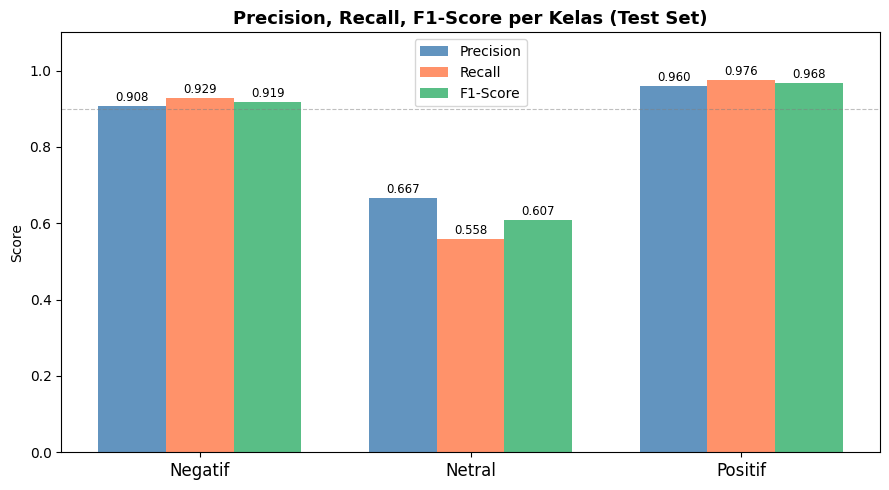

-> 16_metrics_per_kelas.png


In [2]:
labels      = [LABEL_MAP[i] for i in range(3)]
n_actual    = cm.sum(axis=1)
n_predicted = cm.sum(axis=0)

precision = np.diag(cm) / n_predicted
recall    = np.diag(cm) / n_actual
f1        = 2 * precision * recall / (precision + recall)

df_clf = pd.DataFrame({
    'Kelas':     labels,
    'Precision': precision.round(4),
    'Recall':    recall.round(4),
    'F1-Score':  f1.round(4),
    'Support':   n_actual,
})
print(df_clf.to_string(index=False))

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w,     precision, w, label='Precision', color='steelblue',     alpha=0.85)
b2 = ax.bar(x,         recall,    w, label='Recall',    color='coral',          alpha=0.85)
b3 = ax.bar(x + w,     f1,        w, label='F1-Score',  color='mediumseagreen', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1-Score per Kelas (Test Set)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '16_metrics_per_kelas.png'), bbox_inches='tight', dpi=150)
plt.show()
print('-> 16_metrics_per_kelas.png')

## 2. Validasi vs Test

gap val vs test:
  Loss             0.0000
  Accuracy         0.0001
  F1 Weighted      0.0002
  F1 Macro         0.0003


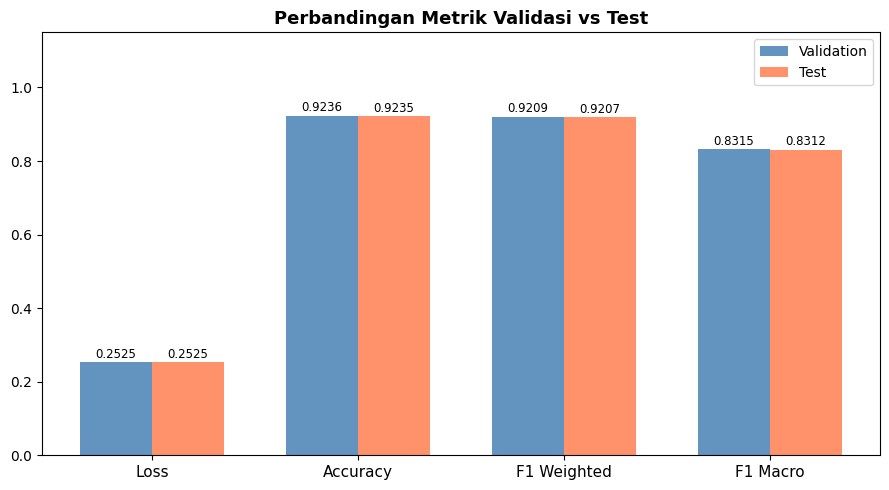

-> 17_val_vs_test.png


In [3]:
kategori  = ['Loss', 'Accuracy', 'F1 Weighted', 'F1 Macro']
val_vals  = [metrics['val']['loss'],  metrics['val']['accuracy'],
             metrics['val']['f1_weighted'],  metrics['val']['f1_macro']]
test_vals = [metrics['test']['loss'], metrics['test']['accuracy'],
             metrics['test']['f1_weighted'], metrics['test']['f1_macro']]

print('gap val vs test:')
for k, v, t in zip(kategori, val_vals, test_vals):
    print(f'  {k:15s}  {abs(v-t):.4f}')

x = np.arange(len(kategori))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, val_vals,  w, label='Validation', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, test_vals, w, label='Test',       color='coral',     alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(kategori, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Perbandingan Metrik Validasi vs Test', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '17_val_vs_test.png'), bbox_inches='tight', dpi=150)
plt.show()
print('-> 17_val_vs_test.png')

## 3. Distribusi Prediksi

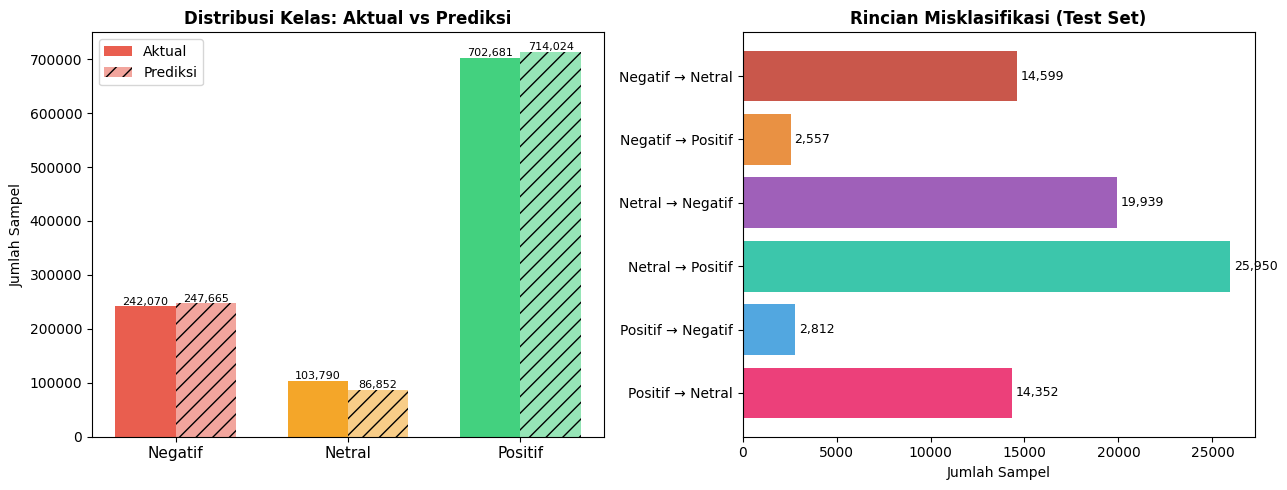

80,209 kesalahan dari 1,048,541 sampel (7.65%)
paling banyak: Netral → Positif  25,950 kasus (25.0% dari kelas Netral)
-> 18_prediction_analysis.png


In [4]:
actual_count = cm.sum(axis=1)
pred_count   = cm.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(3)
w = 0.35
b1 = axes[0].bar(x - w/2, actual_count, w, color=[COLORS[i] for i in range(3)], label='Aktual',   alpha=0.9)
b2 = axes[0].bar(x + w/2, pred_count,   w, color=[COLORS[i] for i in range(3)], label='Prediksi', alpha=0.5, hatch='//')

for bar, v in zip(b1, actual_count):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000, f'{v:,}', ha='center', fontsize=8)
for bar, v in zip(b2, pred_count):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000, f'{v:,}', ha='center', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels([LABEL_MAP[i] for i in range(3)], fontsize=11)
axes[0].set_title('Distribusi Kelas: Aktual vs Prediksi', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].legend()

wrong_pairs  = []
wrong_counts = []
palette = ['#c0392b','#e67e22','#8e44ad','#1abc9c','#3498db','#e91e63']
ci = 0
for i in range(3):
    for j in range(3):
        if i != j:
            wrong_pairs.append(f'{LABEL_MAP[i]} \u2192 {LABEL_MAP[j]}')
            wrong_counts.append(cm[i, j])
            ci += 1

bars = axes[1].barh(wrong_pairs, wrong_counts, color=palette[:len(wrong_pairs)], alpha=0.85)
for bar, v in zip(bars, wrong_counts):
    axes[1].text(v + 200, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)

axes[1].set_title('Rincian Misklasifikasi (Test Set)', fontweight='bold')
axes[1].set_xlabel('Jumlah Sampel')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '18_prediction_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()

total_wrong = cm.sum() - np.diag(cm).sum()
print(f'{total_wrong:,} kesalahan dari {cm.sum():,} sampel ({total_wrong/cm.sum()*100:.2f}%)')
print(f'paling banyak: Netral \u2192 Positif  {cm[1,2]:,} kasus ({cm[1,2]/cm[1].sum()*100:.1f}% dari kelas Netral)')
print('-> 18_prediction_analysis.png')

## 4. Inferensi — Seluruh Test Set

In [5]:
import torch
from scipy.special import softmax as scipy_softmax
from transformers import (
    DistilBertForSequenceClassification, DistilBertTokenizerFast,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

if os.path.exists(CACHE_PREDS):
    print('loading dari cache...')
    data          = np.load(CACHE_PREDS)
    y_pred        = data['y_pred']
    y_true        = data['y_true']
    conf          = data['conf']
    token_lengths = data['token_lengths']
    print(f'{len(y_pred):,} prediksi dimuat')
else:
    ckpt_dirs = sorted(
        [d for d in os.listdir(PATH_MODEL) if d.startswith('checkpoint-')],
        key=lambda x: int(x.split('-')[1])
    )
    best_ckpt = os.path.join(PATH_MODEL, ckpt_dirs[-1])
    DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'device: {DEVICE}  |  checkpoint: {os.path.basename(best_ckpt)}')

    model_inf = DistilBertForSequenceClassification.from_pretrained(best_ckpt)
    model_inf.to(DEVICE).eval()
    tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

    def tokenize_fn(batch):
        return tokenizer(batch['text_clean'], max_length=512, truncation=True, padding=False)

    def compute_metrics_fn(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'accuracy': accuracy_score(labels, preds),
            'f1':       f1_score(labels, preds, average='weighted'),
            'f1_macro': f1_score(labels, preds, average='macro'),
        }

    print('memuat test set dari cache HF...')
    test_ds = load_dataset('csv', data_files=os.path.join(PATH_SPLIT, 'test.csv'),
                           split='train', cache_dir=HF_CACHE)
    test_ds = test_ds.rename_column('sentiment', 'labels')
    test_ds = test_ds.map(tokenize_fn, batched=True, batch_size=1000, desc='tokenizing')
    test_ds = test_ds.remove_columns([
        c for c in test_ds.column_names if c not in ('input_ids', 'attention_mask', 'labels')
    ])
    test_ds.set_format('torch')
    print(f'{len(test_ds):,} sampel siap')

    eval_args = TrainingArguments(
        output_dir=PATH_MODEL,
        per_device_eval_batch_size=64,
        fp16=(DEVICE == 'cuda'),
        report_to='none',
    )
    trainer = Trainer(
        model=model_inf,
        args=eval_args,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics_fn,
    )

    print('inferensi... (estimasi 30-60 menit)')
    preds_out = trainer.predict(test_ds)
    print(f'\nhasil: {preds_out.metrics}')

    logits = preds_out.predictions
    probs  = scipy_softmax(logits, axis=1)
    y_pred = np.argmax(logits, axis=1)
    y_true = preds_out.label_ids.astype(int)
    conf   = probs.max(axis=1)

    print('hitung panjang token...')
    df_texts  = pd.read_csv(os.path.join(PATH_SPLIT, 'test.csv'), usecols=['text_clean'])
    texts_all = df_texts['text_clean'].fillna('').tolist()

    token_lengths = []
    for i in range(0, len(texts_all), 1000):
        batch = texts_all[i : i + 1000]
        enc   = tokenizer(batch, truncation=True, max_length=512,
                          add_special_tokens=True,
                          return_attention_mask=False,
                          return_token_type_ids=False)
        token_lengths.extend(len(ids) for ids in enc['input_ids'])
        if i % 200_000 == 0:
            print(f'  {i:,}/{len(texts_all):,}', end='\r')

    token_lengths = np.array(token_lengths[:len(y_pred)])
    np.savez(CACHE_PREDS, y_pred=y_pred, y_true=y_true, conf=conf, token_lengths=token_lengths)
    print(f'\nsaved -> {CACHE_PREDS}')

print(f'\n{len(y_pred):,} sampel  |  accuracy {(y_pred == y_true).mean():.4f}')

device: cuda  |  checkpoint: checkpoint-1834947


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

memuat test set dari cache HF...


tokenizing:   0%|          | 0/1048541 [00:00<?, ? examples/s]

1,048,541 sampel siap
inferensi... (estimasi 30-60 menit)



hasil: {'test_loss': 0.25248467922210693, 'test_model_preparation_time': 0.0015, 'test_accuracy': 0.9235070445504754, 'test_f1': 0.9207277546182623, 'test_f1_macro': 0.8312445929829845, 'test_runtime': 4057.527, 'test_samples_per_second': 258.419, 'test_steps_per_second': 4.038}
hitung panjang token...
  1,000,000/1,048,541
saved -> D:\big-data-ai-sentiment\outputs\metrics\test_predictions.npz

1,048,541 sampel  |  accuracy 0.9235


## 5. Seberapa Yakin Model?

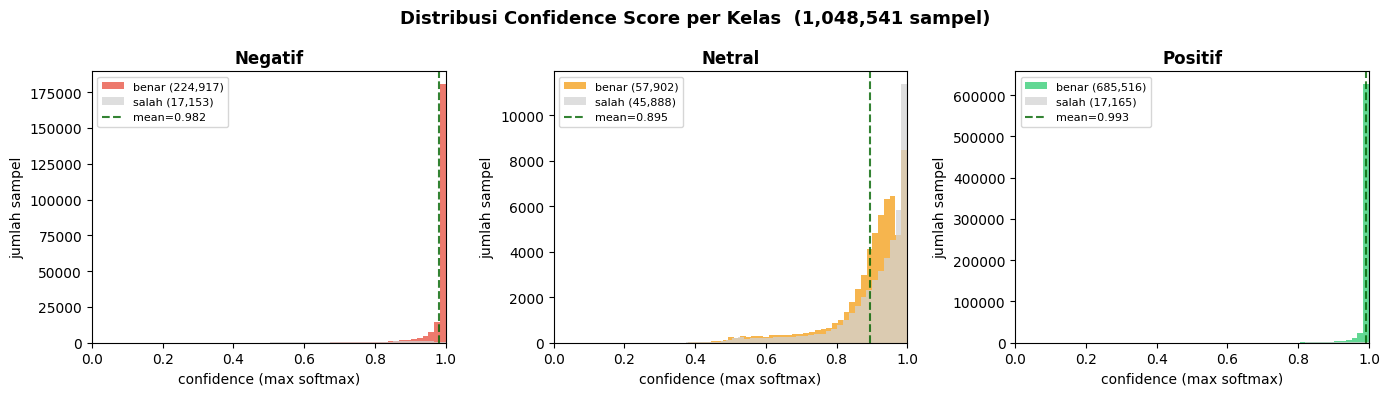

Negatif   benar=0.982  salah=0.833
Netral    benar=0.895  salah=0.909
Positif   benar=0.993  salah=0.830
-> 19_confidence_dist.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    mask    = y_true == i
    correct = conf[mask & (y_pred == y_true)]
    wrong   = conf[mask & (y_pred != y_true)]

    axes[i].hist(correct, bins=40, alpha=0.75, color=COLORS[i],   label=f'benar ({len(correct):,})')
    axes[i].hist(wrong,   bins=40, alpha=0.75, color='lightgray', label=f'salah ({len(wrong):,})')
    if len(correct) > 0:
        axes[i].axvline(correct.mean(), color='darkgreen', linestyle='--',
                        linewidth=1.5, alpha=0.8, label=f'mean={correct.mean():.3f}')
    axes[i].set_title(LABEL_MAP[i], fontweight='bold')
    axes[i].set_xlabel('confidence (max softmax)')
    axes[i].set_ylabel('jumlah sampel')
    axes[i].set_xlim(0, 1)
    axes[i].legend(fontsize=8)

plt.suptitle(f'Distribusi Confidence Score per Kelas  ({len(y_pred):,} sampel)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '19_confidence_dist.png'), bbox_inches='tight', dpi=150)
plt.show()

for i in range(3):
    mask  = y_true == i
    c_ok  = conf[mask & (y_pred == y_true)]
    c_err = conf[mask & (y_pred != y_true)]
    print(f'{LABEL_MAP[i]:8s}  benar={c_ok.mean():.3f}  salah={c_err.mean() if len(c_err) else 0:.3f}')
print('-> 19_confidence_dist.png')

## 6. Pengaruh Panjang Review

         accuracy   count
bucket                   
1–64     0.936246  336996
65–128   0.924901  332855
129–256  0.914130  258168
257–384  0.908528   75127
385–512  0.896839   45395


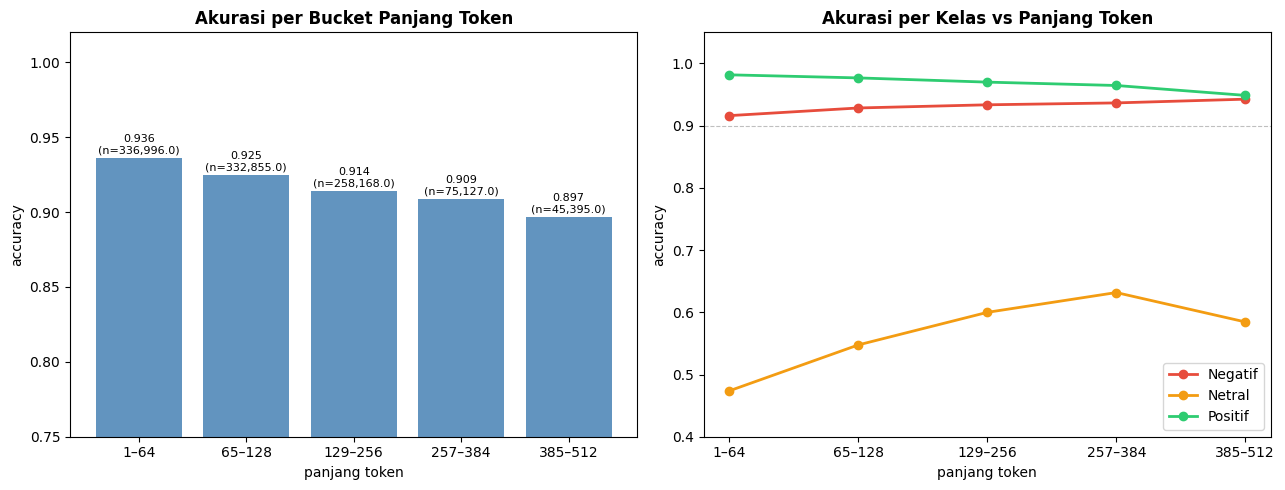

-> 20_akurasi_per_panjang.png


In [7]:
bins    = [0, 64, 128, 256, 384, 512]
blabels = ['1\u201364', '65\u2013128', '129\u2013256', '257\u2013384', '385\u2013512']
bucket  = pd.cut(token_lengths, bins=bins, labels=blabels, right=True)

df_len = pd.DataFrame({'bucket': bucket, 'correct': (y_pred == y_true).astype(int), 'label': y_true})

acc_bucket = df_len.groupby('bucket', observed=True)['correct'].agg(['mean', 'count'])
acc_bucket.columns = ['accuracy', 'count']
print(acc_bucket.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bucket_order = [b for b in blabels if b in acc_bucket.index]
axes[0].bar(bucket_order, acc_bucket.loc[bucket_order, 'accuracy'], color='steelblue', alpha=0.85)
for i, (bk, row) in enumerate(acc_bucket.loc[bucket_order].iterrows()):
    axes[0].text(i, row['accuracy'] + 0.003,
                 f"{row['accuracy']:.3f}\n(n={row['count']:,})", ha='center', fontsize=8)
axes[0].set_ylim(0.75, 1.02)
axes[0].set_title('Akurasi per Bucket Panjang Token', fontweight='bold')
axes[0].set_xlabel('panjang token')
axes[0].set_ylabel('accuracy')

for cls in range(3):
    sub = df_len[df_len['label'] == cls].groupby('bucket', observed=True)['correct'].mean().reindex(blabels)
    axes[1].plot(blabels, sub.values, 'o-', color=COLORS[cls], label=LABEL_MAP[cls], linewidth=2, markersize=6)

axes[1].set_ylim(0.4, 1.05)
axes[1].set_title('Akurasi per Kelas vs Panjang Token', fontweight='bold')
axes[1].set_xlabel('panjang token')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '20_akurasi_per_panjang.png'), bbox_inches='tight', dpi=150)
plt.show()
print('-> 20_akurasi_per_panjang.png')

## 7. Contoh Review yang Salah Klasifikasi

In [8]:
df_text = pd.read_csv(os.path.join(PATH_SPLIT, 'test.csv'), usecols=['text_clean', 'sentiment'])
df_text = df_text.dropna(subset=['text_clean']).reset_index(drop=True)

min_len = min(len(df_text), len(y_pred))
df_text = df_text.iloc[:min_len].copy()
df_text['y_pred'] = y_pred[:min_len]
df_text['y_true'] = y_true[:min_len]
df_text['conf']   = conf[:min_len]

print('=' * 78)
for true_cls in range(3):
    for pred_cls in range(3):
        if true_cls == pred_cls:
            continue
        subset = df_text[(df_text['y_true'] == true_cls) & (df_text['y_pred'] == pred_cls)]
        if len(subset) == 0:
            continue
        row  = subset.nlargest(1, 'conf').iloc[0]
        text = str(row['text_clean'])
        print(f"aktual={LABEL_MAP[true_cls]}  prediksi={LABEL_MAP[pred_cls]}  conf={row['conf']:.3f}  (n={len(subset):,})")
        print(f"  {text[:240]}{'...' if len(text) > 240 else ''}")
        print()
print('=' * 78)

aktual=Negatif  prediksi=Netral  conf=0.999  (n=14,594)
  we ate at amada last night for our first stop during restaurant week. both of us have been wanting to eat here (or at any garces restaurant) for some time, so this seemed to be the perfect opportunity. we had a 7:30 reservation and arrived ...

aktual=Negatif  prediksi=Positif  conf=1.000  (n=2,559)
  this was one of the best experiences i had at a restaurant. the staff was friendly and very helpful with recommendation. the owner came to our table and spoke to us. the food was amazing. i wish i took pictures to post. they had valet parki...

aktual=Netral  prediksi=Negatif  conf=1.000  (n=19,938)
  i went here on september 14, 2017. we were seated for almost 30 minutes before any member of the wait staff acknowledged our presence. my girlfriend went to ask someone at the bar for a second set of utensils because only one set was on our...

aktual=Netral  prediksi=Positif  conf=1.000  (n=25,950)
  i love datz! the waffles n tweet 

## 8. Kesimpulan

In [9]:
total_wrong = cm.sum() - np.diag(cm).sum()

print(f'model  : distilbert-base-uncased, 3 epoch, full dataset ~7M baris')
print(f'test   : {len(y_pred):,} sampel')
print()
print(f'accuracy    {metrics["test"]["accuracy"]:.4f}  ({metrics["test"]["accuracy"]*100:.2f}%)')
print(f'F1 weighted {metrics["test"]["f1_weighted"]:.4f}')
print(f'F1 macro    {metrics["test"]["f1_macro"]:.4f}')
print()
for i in range(3):
    print(f'{LABEL_MAP[i]:8s}  P={precision[i]:.3f}  R={recall[i]:.3f}  F1={f1[i]:.3f}')
print()
print(f'total error  {total_wrong:,} ({total_wrong/cm.sum()*100:.2f}%)')
print(f'error utama  Netral \u2192 Positif: {cm[1,2]:,} kasus ({cm[1,2]/cm[1].sum()*100:.1f}% kelas Netral)')
print()
print('figures: 16_metrics_per_kelas  17_val_vs_test  18_prediction_analysis  19_confidence_dist  20_akurasi_per_panjang')

model  : distilbert-base-uncased, 3 epoch, full dataset ~7M baris
test   : 1,048,541 sampel

accuracy    0.9235  (92.35%)
F1 weighted 0.9207
F1 macro    0.8312

Negatif   P=0.908  R=0.929  F1=0.919
Netral    P=0.667  R=0.558  F1=0.607
Positif   P=0.960  R=0.976  F1=0.968

total error  80,209 (7.65%)
error utama  Netral → Positif: 25,950 kasus (25.0% kelas Netral)

figures: 16_metrics_per_kelas  17_val_vs_test  18_prediction_analysis  19_confidence_dist  20_akurasi_per_panjang
